In [1]:
import importlib
import peak_gene_utils
importlib.reload(peak_gene_utils)
from peak_gene_utils import *

import time
import joblib

from utils import *
import squidpy as sq
import os

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

## Load data

### Annotate cCRE df with three nearest genes

In [2]:
atac = sc.read_h5ad("desc_normalized_atac_peaks.h5ad")
expr = sc.read_h5ad("desc_normalized_rna.h5ad")

In [3]:
niche_pca_anno = sc.read_h5ad("../../h5ad_files/niche_pca_annotated_sp.h5ad")

In [4]:
expr.obs["niche_pca_leiden"] = niche_pca_anno.obs["leiden"].copy()
atac.obs["niche_pca_leiden"] = niche_pca_anno.obs["leiden"].copy()

In [5]:
# get nichePCA pca matrix
X_npca = np.load("../X_npca.npy")
expr.obsm["X_npca"] = X_npca

## Run Descart

In [6]:
num_select_peak = 10000
seed_base = 1
tf = 'tfidf2'
pc = 10
k = 20
similarity = 'cosine'
iter_time = 4
spmethod = 'threshold'
neighbor = 5
sp_dist = 'recip'
pre_select = 'highest'
peaks_num = 50000
distance = 'euclidean'
r = 0.5

'''
start_time = time.time()

#adata = sc.AnnData(adata_raw.X,dtype = 'float32')
idx, sorted_index, simi_matrix, idx_all, scores, selected_peaks_data,similarity_matrix_acb, similarity_matrix_spatial = run_descart(atac, num_select_peak, seed_base=seed_base, tfidf=tf, ifPCA=True, pc=pc, k=k, similarity=similarity, iters=iter_time, spmethod=spmethod,neighbor=neighbor,sp_dist=sp_dist, pre_select=pre_select, peaks_num=peaks_num, distance=distance,r=r)

end_time = time.time()

elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")

descart_output = {
    'idx': idx,
    'sorted_index': sorted_index,
    'simi_matrix': simi_matrix,
    'idx_all': idx_all,
    'scores': scores,
    'selected_peaks_data': selected_peaks_data,
    'similarity_matrix_acb': similarity_matrix_acb,
    'similarity_matrix_spatial': similarity_matrix_spatial
}

joblib.dump(descart_output, 'module_cache/descart_output_r0.5.pkl')  # You can customize the filename based on parameters
print("Saved run_descart output.")
'''

'\nstart_time = time.time()\n\n#adata = sc.AnnData(adata_raw.X,dtype = \'float32\')\nidx, sorted_index, simi_matrix, idx_all, scores, selected_peaks_data,similarity_matrix_acb, similarity_matrix_spatial = run_descart(atac, num_select_peak, seed_base=seed_base, tfidf=tf, ifPCA=True, pc=pc, k=k, similarity=similarity, iters=iter_time, spmethod=spmethod,neighbor=neighbor,sp_dist=sp_dist, pre_select=pre_select, peaks_num=peaks_num, distance=distance,r=r)\n\nend_time = time.time()\n\nelapsed_time = end_time - start_time\nprint(f"Running time: {elapsed_time:.6f} seconds")\n\ndescart_output = {\n    \'idx\': idx,\n    \'sorted_index\': sorted_index,\n    \'simi_matrix\': simi_matrix,\n    \'idx_all\': idx_all,\n    \'scores\': scores,\n    \'selected_peaks_data\': selected_peaks_data,\n    \'similarity_matrix_acb\': similarity_matrix_acb,\n    \'similarity_matrix_spatial\': similarity_matrix_spatial\n}\n\njoblib.dump(descart_output, \'module_cache/descart_output_r0.5.pkl\')  # You can customi

In [7]:
descart_output = joblib.load('module_cache/descart_output_r0.5.pkl')

# Unpack the variables
idx = descart_output['idx']
sorted_index = descart_output['sorted_index']
simi_matrix = descart_output['simi_matrix']
idx_all = descart_output['idx_all']
scores = descart_output['scores']
selected_peaks_data = descart_output['selected_peaks_data']
similarity_matrix_acb = descart_output['similarity_matrix_acb']
similarity_matrix_spatial = descart_output['similarity_matrix_spatial']

print("Loaded cached output.")

Loaded cached output.


In [8]:
start_time = time.time()
pdist_ = peak_modules_(selected_peaks_data=selected_peaks_data, similarity_matrix=simi_matrix, method='complete')
pdist_ = (pdist_+pdist_.T)/2
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")
print("Peak modules calculation has been done.")

pdist_.shape

Running time: 8.241069 seconds
Peak modules calculation has been done.


(10000, 10000)

In [9]:
non_diagonal_values = pdist_[np.triu_indices(pdist_.shape[0], k=1)]
peak_similarity = np.copy(pdist_)
thd = np.percentile(non_diagonal_values, 99.5)
peak_similarity[peak_similarity > thd] = thd
peak_distance = thd - peak_similarity
np.fill_diagonal(peak_distance, 0)

## Get peak modules

In [10]:
#Z,labels = peak_module_cluster(atac,idx,peak_distance,"ward",num_clusters = 5)

In [11]:
'''
cluster_output = {
    'Z': Z,
    'labels': labels
}

joblib.dump(cluster_output, 'module_cache/peak_modules_r0.5_k5.pkl')
print("Saved peak module clustering output.")
'''

'\ncluster_output = {\n    \'Z\': Z,\n    \'labels\': labels\n}\n\njoblib.dump(cluster_output, \'module_cache/peak_modules_r0.5_k5.pkl\')\nprint("Saved peak module clustering output.")\n'

In [12]:
cluster_output = joblib.load('module_cache/peak_modules_r0.5_k5.pkl')

Z = cluster_output['Z']
labels = cluster_output['labels']

print("Loaded peak module clustering from cache.")

Loaded peak module clustering from cache.


In [13]:
def compute_linkage(peak_distance, method='ward'):
    return sch.linkage(peak_distance, method=method)

def get_cluster_labels(Z, num_clusters):
    return sch.fcluster(Z, t=num_clusters, criterion='maxclust')

In [14]:
# Use the existing AnnData with spatially variable peaks
# Ensure the accessibility matrix is log-transformed (if not already)
sc.pp.log1p(atac)

# Run rank_genes_groups on spatial domains
sc.tl.rank_genes_groups(atac, groupby="niche_pca_leiden", method="wilcoxon", use_raw=False)

# Extract the ranked peak names per domain
# This will return a recarray of shape (top_n, n_domains)
ranked_names = atac.uns['rank_genes_groups']['names']

# Convert to DataFrame
domains = ranked_names.dtype.names
ranked_df = pd.DataFrame({domain: ranked_names[domain] for domain in domains})

# Get indices in .var_names
ranked_indices = pd.DataFrame({
    domain: atac.var_names.get_indexer(ranked_df[domain])
    for domain in domains
})

# Output: 
# - ranked_df: DataFrame of top peak names per domain (str)
# - ranked_indices: same shape, but with integer indices
#ranked_df, ranked_indices


/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [34]:
c = ranked_df.head(100)
d = ranked_indices.head(100)

In [35]:
colors = ['#1f77b4', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b', '#c49c94']
sns.set_palette(colors)

result = []
cluster = pd.DataFrame({'idx':idx, 'label':labels})
for i in np.unique(labels):
    data_new = cluster[cluster['label'] == i]
    idx_new = set(list(data_new['idx']))
    result_i = []
    for key in d.keys():
        idx_key = set(list(d[key]))
        result_i.append(len(idx_key.intersection(idx_new)))
    result.append(result_i)
result = pd.DataFrame(np.array(result).T)
result.index = d.keys()
#result.columns = ['1','2','3','4','5','6','7','8', '9']
result.columns = [str(i + 1) for i in range(result.shape[1])]
'''
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))

for i, cluster in enumerate(result.columns):
    row, col = divmod(i, 4)
    sns.barplot(x=result.index, y=result[cluster], ax=axes[row, col])
    axes[row, col].set_title(f'Cluster: {cluster}')
    axes[row, col].set_xticklabels(result.index, rotation=90)
    axes[row, col].set_xlabel('Domain')
    axes[row, col].set_ylabel('Count')

#plt.tight_layout()
#plt.show()
'''

"\nfig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))\n\nfor i, cluster in enumerate(result.columns):\n    row, col = divmod(i, 4)\n    sns.barplot(x=result.index, y=result[cluster], ax=axes[row, col])\n    axes[row, col].set_title(f'Cluster: {cluster}')\n    axes[row, col].set_xticklabels(result.index, rotation=90)\n    axes[row, col].set_xlabel('Domain')\n    axes[row, col].set_ylabel('Count')\n\n#plt.tight_layout()\n#plt.show()\n"

In [36]:
# Create output directories
output_dir = "new_module_domain_barplots"
os.makedirs(output_dir, exist_ok=True)

no_label_output_dir = "new_no_label_module_domain_barplots"
os.makedirs(no_label_output_dir, exist_ok=True)

peak_module_domain_counts = result.copy()
peak_module_domain_counts.columns = [f'Module {i+1}' for i in range(peak_module_domain_counts.shape[1])]

# Normalize counts per module (column-wise → proportion per domain)
peak_module_domain_props = peak_module_domain_counts.div(peak_module_domain_counts.sum(axis=0), axis=1)


for module in peak_module_domain_props.columns:
    # Prepare data
    module_data = peak_module_domain_props[[module]].copy()
    module_data = module_data.rename(columns={module: 'Proportion'})
    module_data = module_data.reset_index().rename(columns={'index': 'Spatial Domain'})

    # === 1. Full version ===
    plt.figure(figsize=(5, 4))
    sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
    plt.title(f"{module}")
    plt.xlabel("Spatial Domain")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    full_path = os.path.join(output_dir, f"{module.replace(' ', '_').lower()}_full.png")
    #plt.savefig(full_path, dpi=150)
    plt.close()
    print(f"✅ Saved full plot: {full_path}")

    # === 2. Clean version ===
    plt.figure(figsize=(5, 4))
    sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
    #plt.xticks([])
    #plt.yticks([])
    plt.xlabel("")
    plt.ylabel("")
    plt.title("")
    plt.ylim(0, 1)
    plt.tight_layout()
    clean_path = os.path.join(no_label_output_dir, f"{module.replace(' ', '_').lower()}_clean.png")
    #plt.savefig(clean_path, dpi=150)
    plt.close()
    print(f"🧼 Saved clean plot: {clean_path}")


/tmp/ipykernel_637103/2145262656.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_637103/2145262656.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')


✅ Saved full plot: new_module_domain_barplots/module_1_full.png
🧼 Saved clean plot: new_no_label_module_domain_barplots/module_1_clean.png


/tmp/ipykernel_637103/2145262656.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_637103/2145262656.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')


✅ Saved full plot: new_module_domain_barplots/module_2_full.png
🧼 Saved clean plot: new_no_label_module_domain_barplots/module_2_clean.png


/tmp/ipykernel_637103/2145262656.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_637103/2145262656.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_637103/2145262656.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')


✅ Saved full plot: new_module_domain_barplots/module_3_full.png
🧼 Saved clean plot: new_no_label_module_domain_barplots/module_3_clean.png
✅ Saved full plot: new_module_domain_barplots/module_4_full.png


/tmp/ipykernel_637103/2145262656.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_637103/2145262656.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_637103/2145262656.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')


🧼 Saved clean plot: new_no_label_module_domain_barplots/module_4_clean.png
✅ Saved full plot: new_module_domain_barplots/module_5_full.png
🧼 Saved clean plot: new_no_label_module_domain_barplots/module_5_clean.png


/tmp/ipykernel_637103/1937366003.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grid = sns.catplot(


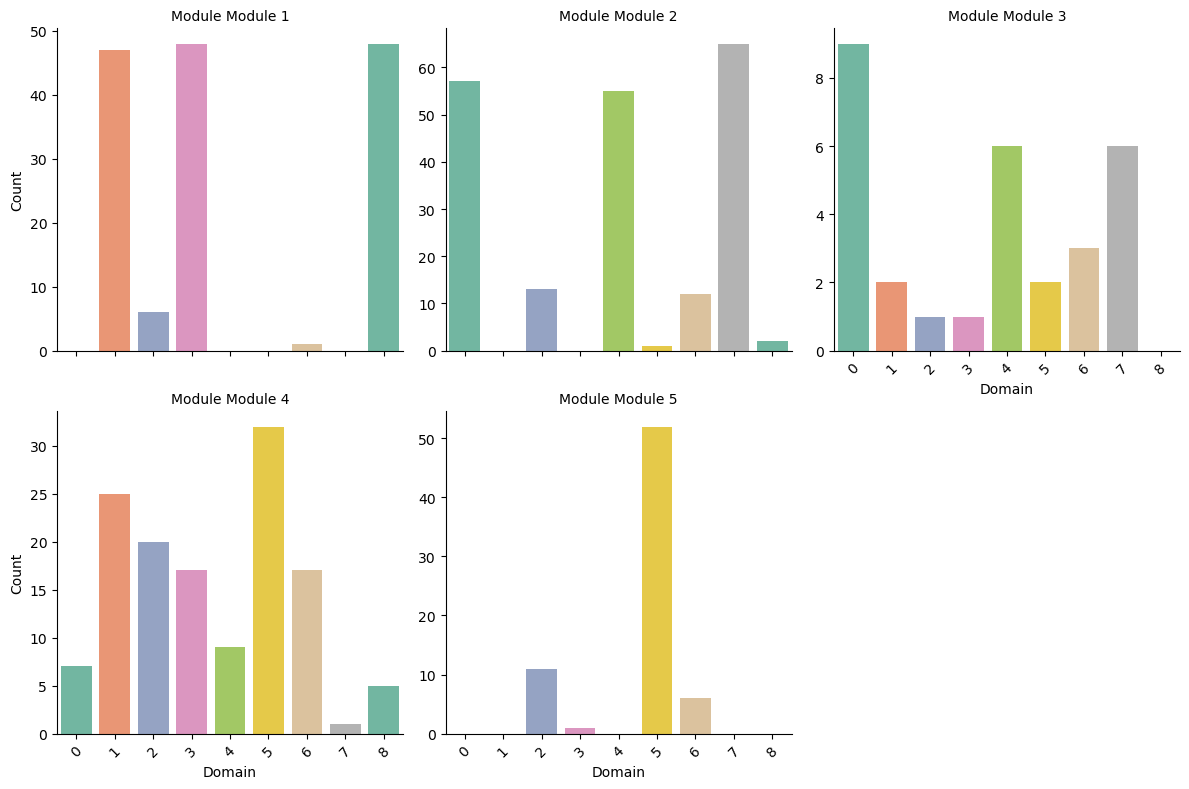

In [37]:
# Rename your existing result DataFrame
peak_module_domain_counts = result.copy()
peak_module_domain_counts.columns = [f'Module {i+1}' for i in range(peak_module_domain_counts.shape[1])]

# Convert to long-form DataFrame
barplot_data = (
    peak_module_domain_counts
    .reset_index()
    .melt(id_vars='index', var_name='Module', value_name='Peak Count')
    .rename(columns={'index': 'Spatial Domain'})
)

# Set order for cleaner plot
barplot_data['Module'] = pd.Categorical(barplot_data['Module'], categories=sorted(peak_module_domain_counts.columns), ordered=True)
barplot_data['Spatial Domain'] = pd.Categorical(barplot_data['Spatial Domain'], categories=sorted(peak_module_domain_counts.index), ordered=True)

# Generate the plot using seaborn
grid = sns.catplot(
    data=barplot_data,
    kind='bar',
    x='Spatial Domain',
    y='Peak Count',
    col='Module',
    col_wrap=3,
    height=4,
    aspect=1,
    palette='Set2',
    sharey=False
)

grid.set_titles("Module {col_name}")
grid.set_axis_labels("Domain", "Count")

# Rotate x-axis labels for readability
for ax in grid.axes.flatten():
    for tick_label in ax.get_xticklabels():
        tick_label.set_rotation(45)

plt.tight_layout()
plt.show()


In [ ]:
from scipy.cluster.hierarchy import leaves_list

pdist_z = scale(pdist_)
pdist_z = (pdist_z + pdist_z.T) / 2
results_z = pd.DataFrame(pdist_z)

ii = leaves_list(Z)
results_z = results_z.iloc[ii, ii]

label_indexed = pd.DataFrame(results_z, index=range(len(labels)))

sorted_results_z = label_indexed.loc[np.argsort(labels), np.argsort(labels)]

name_map = {}
next_mod = 1
for i in sorted_results_z.index:
    mod = labels[i]
    if mod in name_map:
        continue
    if mod == -1:
        continue
    else:
        name_map[int(mod)] = "Module {}".format(next_mod)
        next_mod = next_mod + 1
name_map[-1] = "Module 0"

name_map_r = {v: k for k, v in name_map.items()}

colors = sns.color_palette("muted")
colormap = {i: colors[i % 10] if i != -1 else (1.0, 1.0, 1.0) for i in np.unique(labels)}
colormap_r = {v: k for k, v in colormap.items()}
row_colors1 = pd.Series(
    [colormap[i] for i in labels],
    index=range(10000),
)

row_colors = pd.DataFrame({"Module": row_colors1})
row_colors = row_colors.loc[sorted_results_z.index]

cmap = sns.diverging_palette(230, 20, sep=20, s=85, l=50, as_cmap=True)

cm = sns.clustermap(
    sorted_results_z,
    row_cluster=False,
    col_cluster=False,
    vmin=-8,
    vmax=8,
    cmap=cmap,
    xticklabels=False,
    yticklabels=False,
    row_colors=row_colors,
    rasterized=True,
    cbar_kws=dict(
        label="Z-Score",
#         ticks=[-8, 0, 8],
    ),
)

fig = plt.gcf()
fig.patch.set_visible(False)
plt.sca(cm.ax_heatmap)
plt.ylabel("")
plt.xlabel("")

# Assuming row_colors is ordered, label the groups
plt.sca(cm.ax_row_colors)
for i in row_colors.Module.unique():
    if i == (1.0, 1.0, 1.0):
        continue
    mid = 0
    count = 0
    cl = colormap_r[i]
    for j, x in enumerate(row_colors.Module.values):
        if x == i:
            mid += j
            count += 1

    mid = mid/count

    plt.text(-.4, mid, name_map[cl],
             horizontalalignment='right',
             verticalalignment='center')

plt.show()

In [23]:
peak_modules = pd.Series(data=labels, index=atac.var_names[idx])  # or part of adata.var['module']

In [24]:
atac_10k = atac[:,idx].copy()

In [25]:
# x kb window
window = 50_000

# Prepare peak and gene DataFrames
peaks = atac_10k.var[['chrom', 'start', 'end']].copy()
peaks['peak_id'] = peaks.index
peaks['module'] = peak_modules.loc[peaks.index].values

genes = expr.var[['chrom', 'start', 'end']].copy()
genes['gene_id'] = genes.index

# Make sure coordinates are integers
peaks[['start', 'end']] = peaks[['start', 'end']].astype(int)
# Drop genes with missing coordinates
genes = genes.dropna(subset=['start', 'end'])

# Now safely cast to integers
genes[['start', 'end']] = genes[['start', 'end']].astype(int)
# Initialize output list
links = []

# Iterate chromosome by chromosome (faster, avoids cross-chromosome comparisons)
for chrom in peaks['chrom'].unique():
    peaks_chr = peaks[peaks['chrom'] == chrom]
    genes_chr = genes[genes['chrom'] == chrom]

    # For each peak, find genes within ±100 kb
    for i, peak in peaks_chr.iterrows():
        peak_center = (peak['start'] + peak['end']) // 2
        gene_subset = genes_chr[
            (genes_chr['start'] <= peak_center + window) &
            (genes_chr['end'] >= peak_center - window)
        ]
        for _, gene in gene_subset.iterrows():
            links.append({
                'peak_id': peak['peak_id'],
                'gene_id': gene['gene_id'],
                'module': peak['module'],
                'distance': min(abs(gene['start'] - peak_center), abs(gene['end'] - peak_center))
            })

# Convert to DataFrame
links_df = pd.DataFrame(links)


In [26]:
module_gene_map = links_df.groupby('module')['gene_id'].apply(set).to_dict()

In [27]:
def write_genes(m_g_map, r, num_clusters):
    
    # Create output directory if needed
    os.makedirs(f"{r}_{num_clusters}_module_gene_lists", exist_ok=True)
    
    # Write each module's gene list to a separate .txt file
    for module, genes in m_g_map.items():
        filename = f"{r}_{num_clusters}_module_gene_lists/module_{module}_genes.txt"
        with open(filename, 'w') as f:
            for gene in sorted(genes):  # sorted for readability
                f.write(f"{gene}\n")
        print(f"✅ Saved: {filename} ({len(genes)} genes)")

In [28]:
def write_peak_modules(peak_df, r, num_clusters):
    # Create output directory if needed
    os.makedirs(f"{r}_{num_clusters}_module_peak_beds", exist_ok=True)

    for module_id in range(1, num_clusters+1):
        module_peaks = peak_df[peak_df['module'] == module_id]
    
        bed_df = module_peaks[['chrom', 'start', 'end', 'peak_id']].copy()
        bed_df['score'] = 0
        bed_df['strand'] = '.'
    
        bed_df.to_csv(
            f'{r}_{num_clusters}_module_peak_beds/peak_module_{module_id}.bed',
            sep='\t',
            header=False,
            index=False
        )
    
        print(f"Wrote peak_module_{module_id}.bed with {len(bed_df)} peaks")

In [80]:
atac_all_peaks = sc.read_h5ad("../../h5ad_files/c_atac_spatial_peaks.h5ad")

In [82]:
bed = atac_all_peaks.var[["chrom", "start", "end"]].copy()
bed["name"] = atac_all_peaks.var_names  # optional, to preserve peak ID
bed = bed.reset_index(drop=True)

bed.to_csv("all_peaks.bed", sep="\t", header=False, index=False)

In [ ]:
# Create output directory if needed
os.makedirs(f"{r}_{num_clusters}_module_peak_beds", exist_ok=True)

for module_id in range(1, num_clusters+1):
    module_peaks = peak_df[peak_df['module'] == module_id]

    bed_df = module_peaks[['chrom', 'start', 'end', 'peak_id']].copy()
    bed_df['score'] = 0
    bed_df['strand'] = '.'

    bed_df.to_csv(
        f'{r}_{num_clusters}_module_peak_beds/peak_module_{module_id}.bed',
        sep='\t',
        header=False,
        index=False
    )


In [29]:
#write_peak_modules(peaks, r, 5)

In [30]:
#write_genes(module_gene_map, r, 5)

In [31]:
all_genes = expr.var_names  # or atac_all_peaks.var_names
'''
with open("enrichr_background_genes.txt", "w") as f:
    for gene in all_genes:
        f.write(f"{gene}\n")
'''

'\nwith open("enrichr_background_genes.txt", "w") as f:\n    for gene in all_genes:\n        f.write(f"{gene}\n")\n'

## Which celltypes are modules enriched in?

In [32]:
for module in sorted(peak_modules.unique()):
    peak_ids = peak_modules[peak_modules == module].index
    atac.obs[f'module_{module}_score'] = atac[:, peak_ids].X.mean(axis=1)


In [33]:
for module in sorted(peak_modules.unique()):
    print(atac.obs.groupby('subclass')[f'module_{module}_score'].mean().sort_values(ascending=False).head(5))


subclass
L6 CT         0.948011
L6 IT         0.782107
L5 IT         0.724480
L5 ET         0.668037
L6 IT Car3    0.627509
Name: module_1_score, dtype: float32
subclass
L2/3 IT    0.807134
L4/5 IT    0.787741
L5 IT      0.719086
L6 IT      0.684560
L5 ET      0.625094
Name: module_2_score, dtype: float32
subclass
Endo       1.276115
PVM        0.905275
Peri       0.772614
L2/3 IT    0.714722
L4/5 IT    0.704109
Name: module_3_score, dtype: float32
subclass
Oligo    0.813420
Micro    0.790349
Astro    0.771293
VLMC     0.768384
OPC      0.722264
Name: module_4_score, dtype: float32
subclass
Oligo    1.163275
Astro    1.119958
Endo     1.081831
Peri     0.987141
OPC      0.981259
Name: module_5_score, dtype: float32


/tmp/ipykernel_637103/998575007.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(atac.obs.groupby('subclass')[f'module_{module}_score'].mean().sort_values(ascending=False).head(5))


## Motifs

In [ ]:
import requests

from tqdm import tqdm


In [115]:
def get_jaspar_metadata(matrix_id):
    url = f"https://jaspar.elixir.no/api/v1/matrix/{matrix_id}/"
    r = requests.get(url)
    if r.status_code == 200:
        return r.json()
    return None

In [138]:
def process_fimo_df(path):
    df = pd.read_csv(
    path,
    sep="\t",
    comment="#",  # skip the "#" header comment line
    header=None,  # we’ll set headers manually
    names=[
        "motif_id",
        "sequence_name",
        "start",
        "stop",
        "strand",
        "score",
        "p_value",
        "q_value",
        "matched_sequence"
    ])

    df = df.sort_values("q_value")
    df = df[df["q_value"] <= 0.05]

    unique_ids = df["motif_id"].unique()

    # Collect metadata
    records = []
    for matrix_id in tqdm(unique_ids):
        data = get_jaspar_metadata(matrix_id)
        if data:
            records.append({
                "motif_id": matrix_id,
                "name": data.get("name"),
                "species": data.get("species"),
                "family": data.get("family"),
                "class": data.get("class")
            })
    
    meta_df = pd.DataFrame(records)
    
    # Merge back to FIMO hits
    df_annotated = df.merge(meta_df, on="motif_id", how="left")

    # Extract the first species name from the list of dicts
    df_annotated["species_name"] = df_annotated["species"].apply(
        lambda s: s[0]["name"] if isinstance(s, list) and len(s) > 0 else None
    )
    
    df_mouse = df_annotated[df_annotated["species_name"] == "Mus musculus"]
    
    df_mouse = df_mouse.drop(columns=["species", "family", "class"])
    
    df_mouse = df_mouse[df_mouse["q_value"] < 0.05]
    
    return df_mouse 

In [142]:
fimo_dfs = []

for i in range (1,6):
    fimo_dfs.append(process_fimo_df(f"./fimo_out_bg_module{i}/fimo.txt"))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 77/77 [00:14<00:00,  5.44it/s]


In [151]:
for df in fimo_dfs:
    display(df)

,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
310,MA1540.3,chr10:21764055-21764554,287,298,-,18.4895,1.210000e-07,0.0233,AGTTCAAGGCCA,NR5A1,Mus musculus
311,MA1540.3,chr17:78937569-78938068,367,378,-,20.1538,6.190000e-08,0.0233,AGTTCAAGGTCA,NR5A1,Mus musculus
312,MA1540.3,chr2:181072851-181073350,448,459,+,20.1538,6.190000e-08,0.0233,AGTTCAAGGTCA,NR5A1,Mus musculus
313,MA1540.3,chr11:113948685-113949184,381,392,+,18.4895,1.210000e-07,0.0233,AGTTCAAGGCCA,NR5A1,Mus musculus
314,MA1540.3,chr10:95712102-95712601,394,405,+,18.4895,1.210000e-07,0.0233,AGTTCAAGGCCA,NR5A1,Mus musculus
315,MA1540.3,chr4:47440904-47441403,411,422,+,20.1538,6.190000e-08,0.0233,AGTTCAAGGTCA,NR5A1,Mus musculus
2012,MA0080.7,chr8:93840917-93841416,163,175,+,20.4880,3.090000e-08,0.0346,AAAGAGGAAGTGA,Spi1,Mus musculus


,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
289,MA0860.1,chr5:128845023-128845522,67,83,+,23.9818,9.900000e-09,0.0202,AAGGTCACACAAGGTCA,Rarg,Mus musculus
2362,MA0065.3,chr19:58029609-58030108,484,496,-,19.0000,1.460000e-08,0.0290,AGGGCAAAGGTCA,Pparg::Rxra,Mus musculus
2527,MA0591.2,chr13:75988030-75988529,89,100,-,20.8421,1.190000e-07,0.0348,CATGACTCAGCA,Bach1::Mafk,Mus musculus
2528,MA0591.2,chr4:11017478-11017977,245,256,+,21.2368,5.950000e-08,0.0348,GATGACTCAGCA,Bach1::Mafk,Mus musculus
2530,MA0591.2,chr19:20239411-20239910,214,225,+,20.8421,1.190000e-07,0.0348,CATGACTCAGCA,Bach1::Mafk,Mus musculus
2531,MA0591.2,chr1:165132330-165132829,89,100,+,20.8421,1.190000e-07,0.0348,CATGACTCAGCA,Bach1::Mafk,Mus musculus
2532,MA0591.2,chr13:57017492-57017991,355,366,-,20.8421,1.190000e-07,0.0348,CATGACTCAGCA,Bach1::Mafk,Mus musculus
2533,MA0591.2,chr13:57017492-57017991,395,406,-,20.8421,1.190000e-07,0.0348,CATGACTCAGCA,Bach1::Mafk,Mus musculus
2535,MA0591.2,chr7:139692771-139693270,363,374,-,21.2368,5.950000e-08,0.0348,GATGACTCAGCA,Bach1::Mafk,Mus musculus
2564,MA1540.3,chr8:48763957-48764456,358,369,+,18.4895,1.210000e-07,0.0358,AGTTCAAGGCCA,NR5A1,Mus musculus


,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
207,MA0145.2,chr17:72858169-72858668,342,355,+,18.6600,3.710000e-09,0.00653,CCAGTTCAAACCAG,Tfcp2l1,Mus musculus
3085,MA1540.3,chr6:83143380-83143879,112,123,-,18.4895,1.210000e-07,0.03070,AGTTCAAGGCCA,NR5A1,Mus musculus
3086,MA1540.3,chr7:30194333-30194832,91,102,+,18.4895,1.210000e-07,0.03070,AGTTCAAGGCCA,NR5A1,Mus musculus
3087,MA1540.3,chr8:25017739-25018238,95,106,+,18.4895,1.210000e-07,0.03070,AGTTCAAGGCCA,NR5A1,Mus musculus
3088,MA1540.3,chr2:168742487-168742986,189,200,+,18.4895,1.210000e-07,0.03070,AGTTCAAGGCCA,NR5A1,Mus musculus
3089,MA1540.3,chr13:75227516-75228015,65,76,-,18.4895,1.210000e-07,0.03070,AGTTCAAGGCCA,NR5A1,Mus musculus
3090,MA1540.3,chr5:115212800-115213299,115,126,-,18.4895,1.210000e-07,0.03070,AGTTCAAGGCCA,NR5A1,Mus musculus
3091,MA1540.3,chr12:28535643-28536142,214,225,-,20.1538,6.190000e-08,0.03070,AGTTCAAGGTCA,NR5A1,Mus musculus
3989,MA1573.2,chr2:166727917-166728416,413,426,+,22.0450,1.890000e-08,0.03350,ACTACATTTCCCAG,Thap11,Mus musculus
4208,MA1540.3,chr14:23587389-23587888,409,420,+,18.2867,1.810000e-07,0.03560,AGCTCAAGGTCA,NR5A1,Mus musculus


,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
626,MA1573.2,chr2:144550498-144550997,370,383,-,23.5676,7.580000e-09,0.00898,ACTACAATTCCCAG,Thap11,Mus musculus
627,MA1573.2,chr19:38258632-38259131,102,115,-,23.5676,7.580000e-09,0.00898,ACTACAATTCCCAG,Thap11,Mus musculus
1041,MA1573.2,chr2:30590739-30591238,295,308,+,22.0450,1.890000e-08,0.01490,ACTACATTTCCCAG,Thap11,Mus musculus
1297,MA1573.2,chr1:135373089-135373588,407,420,-,21.9459,2.630000e-08,0.01560,ACTACAAATCCCAG,Thap11,Mus musculus
1439,MA0080.7,chr10:3740125-3740624,236,248,+,21.8560,1.520000e-08,0.01760,AAAGAGGAAGTGG,Spi1,Mus musculus
1445,MA0080.7,chr4:102533852-102534351,330,342,-,21.8560,1.520000e-08,0.01760,AAAGAGGAAGTGG,Spi1,Mus musculus
1531,MA0080.7,chr3:75835456-75835955,278,290,-,20.4880,3.090000e-08,0.01800,AAAGAGGAAGTGA,Spi1,Mus musculus
1532,MA0080.7,chr11:115813885-115814384,126,138,-,20.4880,3.090000e-08,0.01800,AAAGAGGAAGTGA,Spi1,Mus musculus
2073,MA0080.7,chr13:93091852-93092351,216,228,-,20.3680,4.550000e-08,0.02110,GAAGAGGAAGTGG,Spi1,Mus musculus
2600,MA1540.3,chr18:53665902-53666401,12,23,+,18.4895,1.210000e-07,0.02600,AGTTCAAGGCCA,NR5A1,Mus musculus


,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
378,MA1573.2,chr1:16104627-16105126,121,134,+,23.2342,1.130000e-08,0.0049,ACTACAAGTCCCAG,Thap11,Mus musculus
379,MA1573.2,chr1:177796451-177796950,371,384,+,23.5676,7.580000e-09,0.0049,ACTACAATTCCCAG,Thap11,Mus musculus
380,MA1573.2,chr8:4677608-4678107,301,314,-,23.5766,3.710000e-09,0.0049,ACTACAACTCCCAG,Thap11,Mus musculus
381,MA1573.2,chr13:14063291-14063790,266,279,+,23.5676,7.580000e-09,0.0049,ACTACAATTCCCAG,Thap11,Mus musculus
382,MA1573.2,chr7:44997215-44997714,119,132,-,22.0541,1.500000e-08,0.0049,ACTACATCTCCCAG,Thap11,Mus musculus
...,...,...,...,...,...,...,...,...,...,...,...
45596,MA0506.3,chr10:80676268-80676767,459,470,-,15.2800,3.210000e-06,0.0478,CTGCGCAGGCGC,Nrf1,Mus musculus
45620,MA1573.2,chr8:105708025-105708524,238,251,-,17.0901,8.000000e-07,0.0479,ACTACAAACCCCAG,Thap11,Mus musculus
45758,MA0506.3,chr5:29568867-29569366,183,194,-,15.2720,3.260000e-06,0.0482,CCGCGCGTGCGT,Nrf1,Mus musculus
46902,MA0506.3,chr16:76372967-76373466,25,36,+,15.1840,3.420000e-06,0.0498,CTCCGCCTGCGC,Nrf1,Mus musculus


In [152]:
fimo_dfs[4].head(20)

,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
378,MA1573.2,chr1:16104627-16105126,121,134,+,23.2342,1.130000e-08,0.00490,ACTACAAGTCCCAG,Thap11,Mus musculus
379,MA1573.2,chr1:177796451-177796950,371,384,+,23.5676,7.580000e-09,0.00490,ACTACAATTCCCAG,Thap11,Mus musculus
380,MA1573.2,chr8:4677608-4678107,301,314,-,23.5766,3.710000e-09,0.00490,ACTACAACTCCCAG,Thap11,Mus musculus
381,MA1573.2,chr13:14063291-14063790,266,279,+,23.5676,7.580000e-09,0.00490,ACTACAATTCCCAG,Thap11,Mus musculus
382,MA1573.2,chr7:44997215-44997714,119,132,-,22.0541,1.500000e-08,0.00490,ACTACATCTCCCAG,Thap11,Mus musculus
383,MA1573.2,chr4:126202564-126203063,138,151,-,22.0450,1.890000e-08,0.00490,ACTACATTTCCCAG,Thap11,Mus musculus
384,MA1573.2,chr10:81266528-81267027,452,465,-,22.0450,1.890000e-08,0.00490,ACTACATTTCCCAG,Thap11,Mus musculus
385,MA1573.2,chr4:75278056-75278555,289,302,-,22.0450,1.890000e-08,0.00490,ACTACATTTCCCAG,Thap11,Mus musculus
386,MA1573.2,chr8:33385423-33385922,190,203,-,22.0450,1.890000e-08,0.00490,ACTACATTTCCCAG,Thap11,Mus musculus
1016,MA1573.2,chr18:24020158-24020657,251,264,+,21.9459,2.630000e-08,0.00614,ACTACAAATCCCAG,Thap11,Mus musculus


In [146]:
# Make a directory to store the output files
os.makedirs("enrichr_input", exist_ok=True)

# Iterate over your list of FIMO DataFrames
for i, df in enumerate(fimo_dfs):
    # Get unique TF names (gene symbols), drop NAs, sort alphabetically
    tf_symbols = df['name'].dropna().unique()
    tf_symbols.sort()
    
    # Define filename: one per module
    filename = f"enrichr_input/module_{i+1}_tfs.txt"
    
    # Write to file
    with open(filename, "w") as f:
        for symbol in tf_symbols:
            f.write(symbol + "\n")

    print(f"Wrote {len(tf_symbols)} TFs to {filename}")


Wrote 2 TFs to enrichr_input/module_1_tfs.txt
Wrote 4 TFs to enrichr_input/module_2_tfs.txt
Wrote 3 TFs to enrichr_input/module_3_tfs.txt
Wrote 4 TFs to enrichr_input/module_4_tfs.txt
Wrote 9 TFs to enrichr_input/module_5_tfs.txt
